In [2]:
# Reconstruction analysis

import numpy as np
import matplotlib.pyplot as plt
import os

img_path = f'/home/kale-chen/Documents/CASToR/images/'

In [2]:
name1, name2 = 'hcenter_pcut_a', 'mcenter_pcut_a'
#name1, name2 = 'hcenterfinal1', 'mcenterfinal1'
dim = (20, 20, 100)
vox = (1, 1, 1)

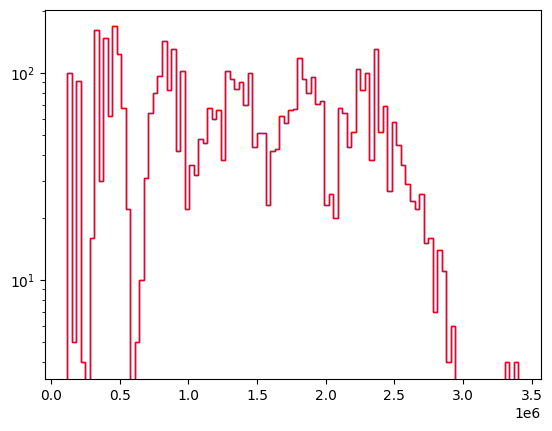

In [4]:
dim = (10, 10, 50)
img = np.fromfile(os.path.join(img_path, name1, f'{name1}_sensitivity.img'), dtype = np.float32)
img2 = np.fromfile(os.path.join(img_path, name2, f'{name2}_sensitivity.img'), dtype = np.float32)
plt.hist(img.flatten(), bins = 100, color = 'blue', histtype = 'step')
plt.hist(img2.flatten(), bins = 100, color = 'red', histtype = 'step')
plt.yscale('log')
plt.show()


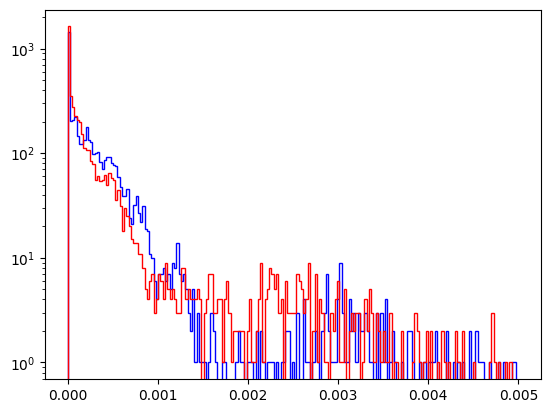

FileNotFoundError: [Errno 2] No such file or directory: '/home/kale-chen/Documents/CASToR/images/hcenter_pcut/hcenter_pcut_it3.img'

In [5]:
#img = np.fromfile(os.path.join(img_path, name, f'{name}_sensitivity.img'), dtype = np.float32)
img = np.fromfile(os.path.join(img_path, name1, f'{name1}_it1.img'), dtype = np.float32).reshape(dim, order = 'F')
img = np.flip(img, axis=1)
img = np.flip(img, axis=2)
imgn = np.fromfile(os.path.join(img_path, name2, f'{name2}_it1.img'), dtype = np.float32).reshape(dim, order = 'F')
imgn = np.flip(imgn, axis=1)
imgn = np.flip(imgn, axis=2)
bins = np.linspace(0, 0.005, 200)
plt.hist(img.flatten(), bins = bins, color = 'blue', histtype = 'step')
plt.hist(imgn.flatten(), bins = bins, color = 'red', histtype = 'step')

#plt.xscale('log')
plt.yscale('log')
plt.show()
img = np.fromfile(os.path.join(img_path, name1, f'{name1}_it3.img'), dtype = np.float32).reshape(dim, order = 'F')
img = np.flip(img, axis=1)
img = np.flip(img, axis=2)
imgn = np.fromfile(os.path.join(img_path, name2, f'{name2}_it3.img'), dtype = np.float32).reshape(dim, order = 'F')
imgn = np.flip(imgn, axis=1)
imgn = np.flip(imgn, axis=2)
bounds = [(26, 38), (26, 38), (32, 96)]
img = img[bounds[0][0]:bounds[0][1], bounds[1][0]:bounds[1][1], bounds[2][0]:bounds[2][1]]
imgn = imgn[bounds[0][0]:bounds[0][1], bounds[1][0]:bounds[1][1], bounds[2][0]:bounds[2][1]]
imgmeanxy = img.sum(axis = 2) / (bounds[2][1] - bounds[2][0])
imgnmeanxy = imgn.sum(axis = 2) / (bounds[2][1] - bounds[2][0])

for i in range(bounds[2][1] - bounds[2][0]):
    img[:, :, i] = img[:, :, i] / imgmeanxy
    imgn[:, :, i] = imgn[:, :, i] / imgnmeanxy

print(len(img.flatten()), len(imgn.flatten()))
bins = np.linspace(0, 2, 100)
plt.hist(img.flatten(), bins = bins, color = 'blue', histtype = 'step')
plt.hist(imgn.flatten(), bins = bins, color = 'red', histtype = 'step')
plt.yscale('log')
plt.show()



In [2]:
it = 1
bounds = [(0, 10), (0, 10), (0, 50)]
img = np.fromfile(os.path.join(img_path, name1, f'{name1}_it{it}.img'), dtype = np.float32).reshape(dim, order = 'F')
img = np.flip(img, axis=1)
img = np.flip(img, axis=2)
imgn = np.fromfile(os.path.join(img_path, name2, f'{name2}_it{it}.img'), dtype = np.float32).reshape(dim, order = 'F')
imgn = np.flip(imgn, axis=1)
imgn = np.flip(imgn, axis=2)
sens = np.fromfile(os.path.join(img_path, name1, f'{name1}_sensitivity.img'), dtype = np.float32).reshape(dim, order = 'F')
sens = np.flip(sens, axis=1)
sens = np.flip(sens, axis=2)
sensn = np.fromfile(os.path.join(img_path, name2, f'{name2}_sensitivity.img'), dtype = np.float32).reshape(dim, order = 'F')
sensn = np.flip(sensn, axis=1)
sensn = np.flip(sensn, axis=2)
img = img[bounds[0][0]:bounds[0][1], bounds[1][0]:bounds[1][1], bounds[2][0]:bounds[2][1]]
imgn = imgn[bounds[0][0]:bounds[0][1], bounds[1][0]:bounds[1][1], bounds[2][0]:bounds[2][1]]
print(np.mean(img), np.mean(imgn))
sens = sens[bounds[0][0]:bounds[0][1], bounds[1][0]:bounds[1][1], bounds[2][0]:bounds[2][1]]
sensn = sensn[bounds[0][0]:bounds[0][1], bounds[1][0]:bounds[1][1], bounds[2][0]:bounds[2][1]]
imgmean = img.sum() / (bounds[2][1] - bounds[2][0])
imgnmean = imgn.sum() / (bounds[2][1] - bounds[2][0])
sensmean = sens.sum() / (bounds[2][1] - bounds[2][0])
sensnmean = sensn.sum() / (bounds[2][1] - bounds[2][0])
center = [(bounds[0][1] - bounds[0][0]) / 2, (bounds[1][1] - bounds[1][0]) / 2, (bounds[2][1] - bounds[2][0]) / 2]
trimdims = (bounds[0][1] - bounds[0][0], bounds[1][1] - bounds[1][0], bounds[2][1] - bounds[2][0])
extenty = (-trimdims[1] / 2 * 0.5, trimdims[1] / 2 * 0.5)
extentz = (-trimdims[2] / 2 * 0.5, trimdims[2] / 2 * 0.5)
print(extenty, extentz)
print(imgmean, imgnmean)


slices, slicesn = [], []
for i in range(bounds[2][1] - bounds[2][0]):
    slices.append(img[:, :, i].sum() / imgmean)
    slicesn.append(imgn[:, :, i].sum() / imgnmean)
slices.insert(0, slices[0])
slicesn.insert(0, slicesn[0])

plotsheight = 6
heatmapwidth = (bounds[1][1] - bounds[1][0]) / (bounds[2][1] - bounds[2][0]) * plotsheight
print(heatmapwidth)
plotswidth = 2 * heatmapwidth + 2
#vmin, vmax = 0, 0.3
fig, ax = plt.subplots(1, 3, figsize = (plotswidth, plotsheight), width_ratios = [heatmapwidth, heatmapwidth, heatmapwidth], height_ratios = [1], sharey=True)
collapsex = img.sum(axis = 0) / imgmean
ax[0].imshow(collapsex.T, cmap = 'jet', extent = [extenty[0], extenty[1], extentz[0], extentz[1]])
collapsex = imgn.sum(axis = 0) / imgnmean
ax[1].imshow(collapsex.T, cmap = 'jet', extent = [extenty[0], extenty[1], extentz[0], extentz[1]])
#collapsex = sens.sum(axis = 0) / sensn.sum(axis = 0)
#collapsex = sens.sum(axis = 0) / sensmean
#ax[2].imshow(collapsex.T, cmap = 'jet')
ax[2].step(slices, np.linspace(extentz[1], extentz[0], bounds[2][1] - bounds[2][0] + 1), where = 'post', color = 'blue', label = 'un')
ax[2].step(slicesn, np.linspace(extentz[1], extentz[0], bounds[2][1] - bounds[2][0] + 1), where = 'post', color = 'red', label = 'norm')
#x[2].set_xlim(0.5, 1.5)
ax[2].set_xlim(0.78, 1.22)

ax[0].set_xlabel('y (mm)')
ax[0].set_ylabel('z (mm)')
ax[1].set_xlabel('y (mm)')
ax[2].set_xlabel('Relative slice\nintensity')
ax[0].set_title('Unnormalized')
ax[1].set_title('Normalized')
ax[2].legend()
plt.tight_layout()
plt.subplots_adjust(hspace=1, wspace=0.1) # Spacing
plt.show()


NameError: name 'name1' is not defined

In [261]:
slices, slicesn = np.array(slices), np.array(slicesn)
slicesdiffs = slices[1:] - slices[:-1]
slicesdiffsn = slicesn[1:] - slicesn[:-1]
print(np.std(slicesdiffs), np.std(slicesdiffsn), np.std(slices), np.std(slicesn))


0.061302662 0.041742634 0.0688434 0.049639042


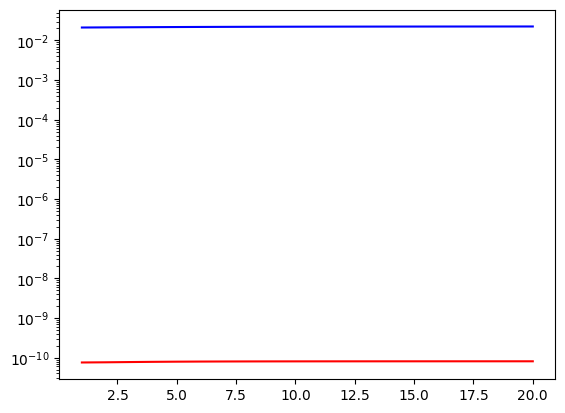

In [46]:
means, meansn = [], []
volume = (bounds[0][1] - bounds[0][0]) * (bounds[1][1] - bounds[1][0]) * (bounds[2][1] - bounds[2][0])
for i in range(1, 21):
    img = np.fromfile(os.path.join(img_path, name1, f'{name1}_it{i}.img'), dtype = np.float32).reshape(dim, order = 'F')
    means.append(np.sum(img) / volume)
    img = np.fromfile(os.path.join(img_path, name2, f'{name2}_it{i}.img'), dtype = np.float32).reshape(dim, order = 'F')
    meansn.append(np.sum(img) / volume)

plt.plot(np.arange(1, 21), means, color = 'blue')
plt.plot(np.arange(1, 21), meansn, color = 'red')
plt.yscale('log')
plt.show()


(20, 20, 100) (1, 1, 1) [(1, 19), (8, 14), (5, 95)] [(1, 19), (3, 12), (5, 95)]
0.00036859245 8.2799874e-05 4.4516063
0.081082106 0.059116174


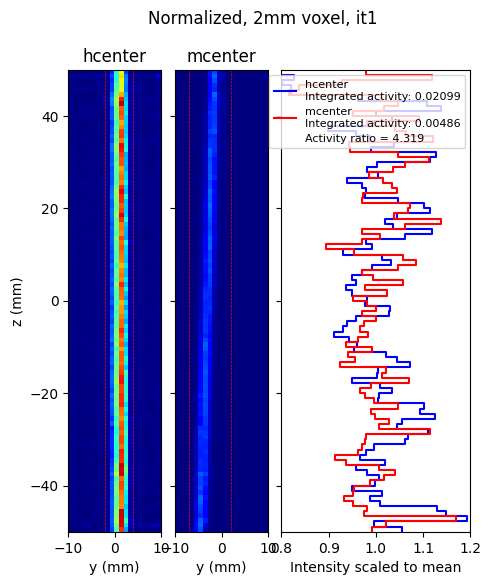

(20, 20, 100) (1, 1, 1) [(1, 19), (8, 14), (5, 95)] [(1, 19), (3, 12), (5, 95)]
0.0003680066 8.4115054e-05 4.3750386
0.08704302 0.08174146


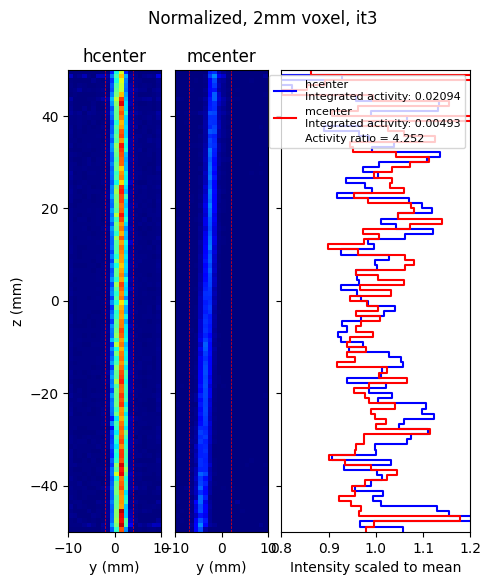

(20, 20, 100) (1, 1, 1) [(1, 19), (8, 14), (5, 95)] [(1, 19), (3, 12), (5, 95)]
0.0003688531 8.4957064e-05 4.3416414
0.110450886 0.15597343


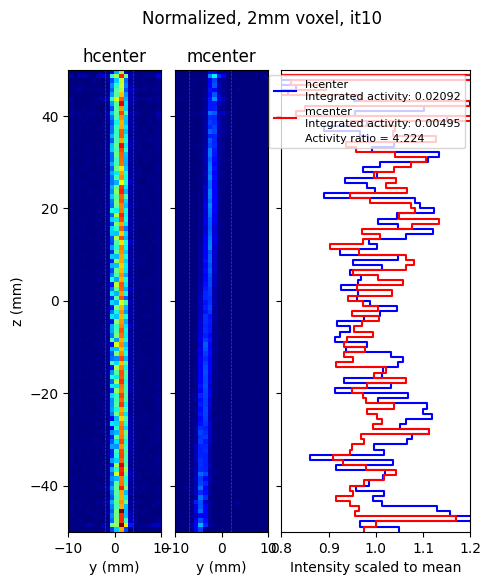

(20, 20, 100) (1, 1, 1) [(1, 19), (8, 14), (5, 95)] [(1, 19), (3, 12), (5, 95)]
0.0003835098 8.449935e-05 4.5386124
0.19236928 0.28579062


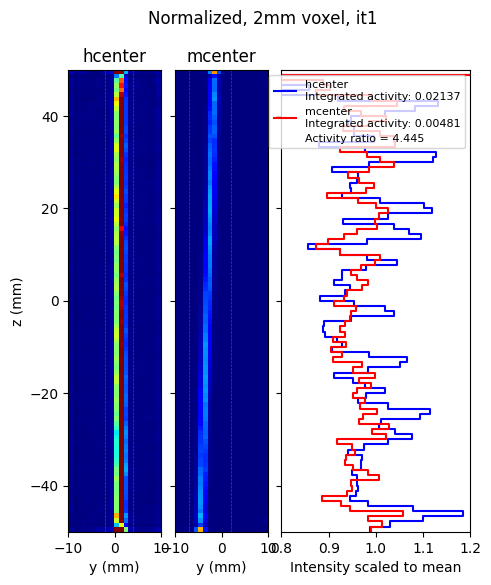

(20, 20, 100) (1, 1, 1) [(1, 19), (8, 14), (5, 95)] [(1, 19), (3, 12), (5, 95)]
0.00038581123 8.468594e-05 4.5557885
0.22463985 0.3129446


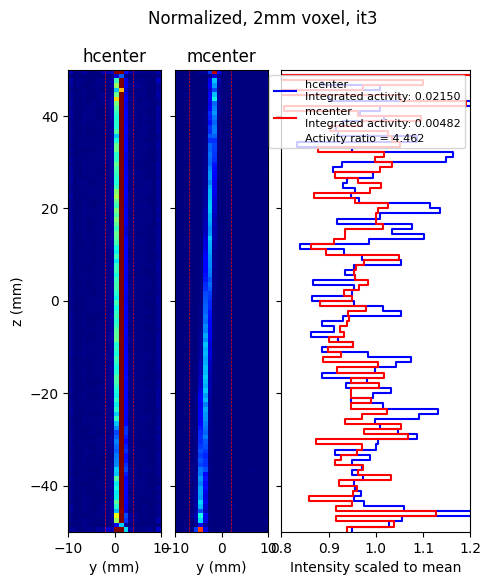

(20, 20, 100) (1, 1, 1) [(1, 19), (8, 14), (5, 95)] [(1, 19), (3, 12), (5, 95)]
0.00038648397 8.487207e-05 4.553724
0.26140773 0.35084683


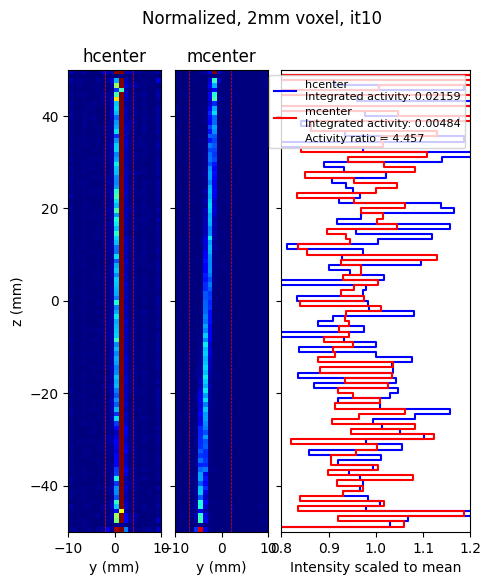

In [ ]:
name1i, name2i = 'hcenterpgd', 'mcenterpgd'
#name1, name2 = 'hcenterpsi2', 'mcenterpsi2'
#name1, name2 = 'hcenterp1', 'mcenterp1'
#name1, name2 = 'hcenterps1', 'mcenterps1'
#tags = ['1', '1n', '2', '2n']
tags = ['ns']
ratios = [[] for _ in range(len(tags))]
iterations = [1, 3, 10]
for t in range(len(tags)):
    name1, name2 = name1i + tags[t], name2i + tags[t]
    for it in iterations:
        if '1' in name1:
            dim = (20, 20, 100)
            vox = (1, 1, 1)
            bounds1 = [(1, 19), (8, 14), (5, dim[2]-5)]
            bounds2 = [(1, 19), (3, 12), (5, dim[2]-5)]
        elif '2' in name1:
            dim = (10, 10, 50)
            vox = (2, 2, 2)
            bounds1 = [(1, 9), (4, 8), (0, dim[2])]
            bounds2 = [(1, 9), (1, 6), (0, dim[2])]
        else:
            dim = (20, 20, 100)
            vox = (1, 1, 1)
            bounds1 = [(1, 19), (8, 14), (5, dim[2]-5)]
            bounds2 = [(1, 19), (3, 12), (5, dim[2]-5)]
        print(dim, vox, bounds1, bounds2)

        img1 = np.fromfile(os.path.join(img_path, name1, f'{name1}_it{it}.img'), dtype = np.float32).reshape(dim, order = 'F')
        img1 = np.flip(img1, axis=1)
        img1 = np.flip(img1, axis=2)
        img2 = np.fromfile(os.path.join(img_path, name2, f'{name2}_it{it}.img'), dtype = np.float32).reshape(dim, order = 'F')
        img2 = np.flip(img2, axis=1)
        img2 = np.flip(img2, axis=2)
        print(np.mean(img1), np.mean(img2), (np.sum(img1) / np.sum(img2)))
        extenty = (-dim[1] * vox[1] / 2, dim[1] * vox[1] / 2)
        extentz = (-dim[2] * vox[2] / 2, dim[2] * vox[2] / 2)
        slices1, slices2 = [], []
        for i in range(bounds1[2][1] - bounds1[2][0]):
            slices1.append(img1[bounds1[0][0]:bounds1[0][1], bounds1[1][0]:bounds1[1][1], i].sum())
        for i in range(bounds2[2][1] - bounds2[2][0]):
            slices2.append(img2[bounds2[0][0]:bounds2[0][1], bounds2[1][0]:bounds2[1][1], i].sum())
        slices1.insert(0, slices1[0])
        slices2.insert(0, slices2[0])
        slices1 = np.array(slices1)
        slices2 = np.array(slices2)
        #print(len(slices1), len(slices2))
        plotsheight = 6
        heatmapwidth = (dim[1] * vox[1]) / (dim[2] * vox[2]) * plotsheight
        plotswidth = 4 * heatmapwidth + 0.4
        #print(plotswidth, plotsheight)
        fig, ax = plt.subplots(1, 3, figsize = (plotswidth, plotsheight), width_ratios = [1, 1, 2], sharey=True)
        collapsex1 = img1.sum(axis = 0)
        collapsex2 = img2.sum(axis = 0)
        #vmin, vmax = min(np.min(collapsex1), np.min(collapsex2)), max(np.max(collapsex1), np.max(collapsex2))
        #print(vmin, vmax)
        #vmax = 0.9 * vmax
        vmax = 10*np.mean(collapsex1)
        ax[0].imshow(collapsex1.T, cmap = 'jet', extent = [extenty[0], extenty[1], extentz[0], extentz[1]], vmin = vmin, vmax = vmax)
        ax[1].imshow(collapsex2.T, cmap = 'jet', extent = [extenty[0], extenty[1], extentz[0], extentz[1]], vmin = vmin, vmax = vmax)
        ax[0].set_ylim(extentz[0], extentz[1])
        cutimg1 = img1[bounds1[0][0]:bounds1[0][1], bounds1[1][0]:bounds1[1][1], bounds1[2][0]:bounds1[2][1]]
        cutimg2 = img2[bounds2[0][0]:bounds2[0][1], bounds2[1][0]:bounds2[1][1], bounds2[2][0]:bounds2[2][1]]
        ax[2].step(slices1 / np.mean(slices1), np.linspace(extentz[1], extentz[0], bounds1[2][1] - bounds1[2][0] + 1), where = 'post', color = 'blue', 
            label = f'hcenter\nIntegrated activity: {np.sum(cutimg1) / 600:.5f}')
        ax[2].step(slices2 / np.mean(slices2), np.linspace(extentz[1], extentz[0], bounds2[2][1] - bounds2[2][0] + 1), where = 'post', color = 'red', 
            label = f'mcenter\nIntegrated activity: {np.sum(cutimg2) / 600:.5f}')
        print(np.std(slices1 / np.mean(slices1)), np.std(slices2 / np.mean(slices2)))
        ax[0].vlines(-dim[1] * vox[1] / 2 + bounds1[1][0] * vox[1], extentz[0], extentz[1], color = 'red', linestyle = '--', linewidth = 0.5)
        ax[0].vlines(-dim[1] * vox[1] / 2 + bounds1[1][1] * vox[1], extentz[0], extentz[1], color = 'red', linestyle = '--', linewidth = 0.5)
        ax[1].vlines(-dim[1] * vox[1] / 2 + bounds2[1][0] * vox[1], extentz[0], extentz[1], color = 'red', linestyle = '--', linewidth = 0.5)
        ax[1].vlines(-dim[1] * vox[1] / 2 + bounds2[1][1] * vox[1], extentz[0], extentz[1], color = 'red', linestyle = '--', linewidth = 0.5)
        ax[0].set_xlabel('y (mm)')
        ax[0].set_ylabel('z (mm)')
        ax[1].set_xlabel('y (mm)')
        ax[0].set_title('hcenter')
        ax[1].set_title('mcenter')
        ax[2].set_title('')
        ax[2].set_xlabel('Intensity scaled to mean')
        ax[2].plot([0], [0], linewidth = 0, label = f'Activity ratio = {np.sum(cutimg1) / np.sum(cutimg2):.3f}')
        ax[2].legend(fontsize = 8, framealpha = 0.8, loc = 'upper right')
        ax[2].set_xlim(0.8, 1.2)
        title = 'Normalized, ' if name1[-1] == 'n' else 'Unnormalized, '
        title = title + '1mm voxel' if '1' in name1 else title + '2mm voxel'
        title = title + f', it{it}'
        plt.suptitle(title)
        plt.subplots_adjust(hspace=0, wspace=0.1) # Spacing
        #plt.savefig(f'/home/kale-chen/Documents/PET/Sensitivity Normalization/writeup/plots/activityrecon/{tags[t]}it{it}.pdf', format="pdf", dpi=300, bbox_inches="tight")
        plt.show()
        ratios[t].append(np.sum(cutimg1) / np.sum(cutimg2))


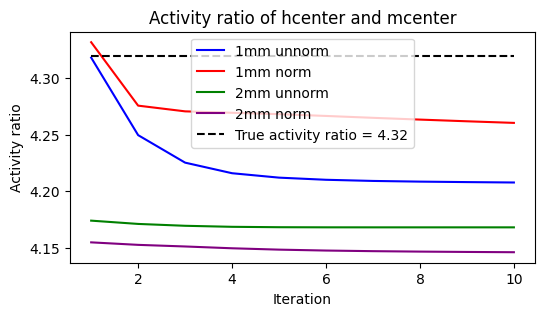

In [40]:
# Plot ratios
plt.figure(figsize = (6, 3))
plt.plot(np.arange(1, 11), ratios[0], color = 'blue', label = '1mm unnorm')
plt.plot(np.arange(1, 11), ratios[1], color = 'red', label = '1mm norm')
plt.plot(np.arange(1, 11), ratios[2], color = 'green', label = '2mm unnorm')
plt.plot(np.arange(1, 11), ratios[3], color = 'purple', label = '2mm norm')
plt.hlines(4.32, 1, 10, color = 'black', linestyle = '--', label = 'True activity ratio = 4.32')
plt.xlabel('Iteration')
plt.ylabel('Activity ratio')
plt.title('Activity ratio of hcenter and mcenter')
plt.legend()
plt.savefig(f'/home/kale-chen/Documents/PET/Sensitivity Normalization/writeup/plots/activityrecon/ratios.pdf', format="pdf", dpi=300, bbox_inches="tight")
plt.show()

